# Convex QP-MPC (= converged ADMM-MPC) — closed-loop control on the exact CTM

**Idea.** At each 15-second step: read the *true* exact-CTM state, solve a short **K-step** convex QP, apply
**only the first** ramp command, advance the **exact non-linear CTM** one step, repeat. Each window is the same
convex program the 2-block consensus ADMM solves (Cell 5 verifies on representative windows that they return nearly identical first commands), so this is
ADMM-MPC; the QP is used per step only because it re-solves hundreds of times faster.

**This run is the fair, capped configuration.** The command authority bound `0 ≤ u ≤ u_max` from the
formulation is **active**: `METER = ARR_MULT` sets `u_max = arrival_multiplier × observed`, and the *same* bound
is applied to the open-loop full-horizon controller, so the two optimisation controllers are compared on equal
footing. Everything is computed in-notebook — file names auto-found, arrival multiplier read from data,
baselines recomputed, every solve status-checked.

**What to expect (all numbers are produced by the cells below, not asserted here):**
- MPC re-plans from the true state each step, so it corrects the convex relaxation's optimism (realized
  capacity penalties stay ≈ 0). On exact-CTM raw objective it is the **best** of {benchmark, fixed, open-loop,
  MPC}.
- The advantage comes from **feedback, not lookahead**: The horizon comparison shows that K=10 gives only a small improvement over K=5.
- **Read the result correctly:** MPC wins the *raw objective* by cutting ramp delay and spillback hard. It is
  **not** a mainline-delay winner — its mainline delay is higher than the benchmark's (the benchmark's low
  mainline is bought with catastrophic spillback). See Cell 9.


In [1]:
# 1. Robust loading + parameters (no hardcoded file names, no hardcoded 1.2)
import glob, os, pickle, time, json, sys, types, io, contextlib
import numpy as np, pandas as pd, cvxpy as cp

def find_file(patterns):
    for pat in patterns:
        hits=sorted(glob.glob(pat), key=os.path.getmtime, reverse=True)
        if hits: return hits[0]
    raise FileNotFoundError("none of: %s"%patterns)
PKL = find_file(["shared_benchmark_inputs.pkl","shared_benchmark_inputs*.pkl","*shared_benchmark_inputs*.pkl"])
NBK = find_file(["Benchmark_calculation_CLEAN.ipynb","Benchmark_calculation*CLEAN*.ipynb","Benchmark_calculation*.ipynb"])
print("using data   :", PKL)
print("using exact-CTM notebook:", NBK)

S=pickle.load(open(PKL,"rb"))
cells=[f"Cell {i}" for i in range(1,10)]; ramps=S["ramp_ids"]; NS=int(S["num_steps"]); dt=float(S["delta_t"]); nR=len(ramps)
ARR_MULT=float(S["arrival_multiplier"])                       # read from data, never hardcoded
mu  =np.array([S["movement_factor_by_cell"][c] for c in cells]); w=np.array([S["wave_speed_ratio_by_cell"][c] for c in cells])
Cin =np.array([S["inflow_capacity"][c] for c in cells]);  Cout=np.array([S["outflow_capacity"][c] for c in cells])
Xmax=np.array([S["physical_capacity"][c] for c in cells]); Xsafe=np.array([S["safe_threshold_capacity"][c] for c in cells])
beta=np.array([S["exit_split_by_cell"][c] for c in cells]); tau =np.array([S["tt_ff_min"][c] for c in cells])
e=np.array([[S["external_inflow_series"][k][c] for k in range(NS)] for c in cells])
f=np.array([[S["fixed_outflow_series"][k][c]   for k in range(NS)] for c in cells])
obs=np.array([[float(S["observed_release_series"][r][k]) for k in range(NS)] for r in ramps])
a = ARR_MULT*obs
d=np.array([float(S["q_in_boundary_series"][k]) for k in range(NS)])
Rmax=np.array([S["ramp_max_queue_by_u"][r] for r in ramps])
gamma=float(S["gamma"]); l1=float(S["lambda_1"]); l2=float(S["lambda_2"]); l3=float(S["lambda_3"]); l4=float(S["lambda_4"])
cidx={c:i for i,c in enumerate(cells)}; M=np.zeros((9,nR))
for j,r in enumerate(ramps): M[cidx[S["ramp_cell_map"][r]],j]=1.0
bt=S["official_totals"]

#  experiment knobs
K = 5
AW = 2.3  # best raw-objective setting from the K x AW sensitivity sweep
METER = ARR_MULT  # ramp authority cap: u_max = METER*observed. ARR_MULT(=1.2) is the fair bound. Set 0 to disable.
BIG=1e6; umax_all = (METER*obs) if METER>0 else np.full_like(obs,BIG)
OPENLOOP_AW = 3.2 # open-loop full-horizon optimum weight (from the QP frontier)
print("ramps=%d steps=%d arrival_multiplier=%.2f | K=%d AW=%.2f METER=%s (u_max cap %s)"%(
      nR,NS,ARR_MULT,K,AW,("%.2f"%METER if METER>0 else "off"),"ACTIVE" if METER>0 else "disabled"))


using data   : shared_benchmark_inputs.pkl
using exact-CTM notebook: Benchmark_calculation.ipynb
ramps=4 steps=480 arrival_multiplier=1.20 | K=5 AW=2.30 METER=1.20 (u_max cap ACTIVE)


In [2]:
# 2. Exact non-linear CTM (the TRUE plant); linear spillback to match the objective; auto-validated
def _noop(*a,**k): pass
for m in ["matplotlib","matplotlib.pyplot","seaborn"]:
    try: __import__(m)
    except Exception: sys.modules[m]=types.ModuleType(m)
_nb=json.load(open(NBK)); _cc=[c for c in _nb["cells"] if c["cell_type"]=="code"]
G={"display":_noop,"__name__":"__main__"}
with contextlib.redirect_stdout(io.StringIO()):
    for i,c in enumerate(_cc[:6]):
        src="".join(l for l in c["source"] if not l.strip().startswith("%"))
        src=src.replace("spillback_penalty = lambda_4 * spillback_excess ** 2","spillback_penalty = lambda_4 * spillback_excess")
        exec(compile(src,"<clean>","exec"),G)
_ctm=G["ctm_15sec_step"]; _rreq=G["ramp_requested_release_one_step"]; _rnq=G["ramp_next_queue_after_actual_release"]
_mds=G["mainline_delay_one_step"]; _rdel=G["ramp_delay_with_cap"]; _fair=G["fairness_penalty_one_step"]; _cpen=G["capacity_penalty_one_step"]
_inf=G["ctm_inflow_capacity_official"]; _out=G["ctm_outflow_capacity_official"]; _phys=G["physical_capacity"]; _safe=G["safe_threshold_capacity"]
_mvf=G["movement_factor_by_cell_official"]; _wav=G["wave_speed_ratio_by_cell_official"]; _exb=G["exit_split_by_cell"]; _MP=G["MERGE_PRIORITY"]
_ttf=G["tt_ff_min"]; _rnm=G["ramp_name_map"]; _rmqn=G["ramp_max_queue_named"]; _rmqu=G["ramp_max_queue_by_u"]
_qb=G["q_in_boundary_series"]; _ext=G["external_inflow_series"]; _fix=G["fixed_outflow_series"]; _cmd=G["commanded_release_series"]
_x0=G["mainline_initial_state"]; _R0=G["ramp_queue_0"]; _dtE=G["delta_t"]; _gam=G["gamma"]
_L1,_L2,_L3,_L4=G["lambda_1"],G["lambda_2"],G["lambda_3"],G["lambda_4"]
def true_step(xc,R,B,Uc,cmd,t):
    arr={r:ARR_MULT*float(_cmd[r][t]) for r in ramps}
    av,req=_rreq(R_current=R,B_current=B,ramp_arrival_step=arr,commanded_release_step=cmd)
    o=_ctm(x_current=xc,q_in_boundary_step=float(_qb[t]),external_inflow_step=_ext[t],fixed_outflow_step=_fix[t],
           requested_release_step=req,inflow_capacity=_inf,outflow_capacity=_out,physical_capacity=_phys,
           movement_factor_by_cell=_mvf,wave_speed_ratio_by_cell=_wav,upstream_boundary_queue=Uc,exit_split_by_cell=_exb,merge_priority=_MP)
    xn,qo,qi=o[0],o[1],o[2]; afo=o[6]; ar=o[9]; ci=o[10]; Un=o[11]; Ud=o[12]
    Rn,Bn,spk=_rnq(available_demand_step=av,actual_release_step=ar,ramp_max_queue_by_u=_rmqu)
    _,ld=_rdel(R,Rn,B,Bn,arr,cmd,req,ar,_dtE); _,_,Lf=_fair(Rn,_rnm,_rmqn,_gam)
    _,_,mc=_mds(xc,xn,qo,afo,_ttf,_dtE); mdl=mc+Ud
    cap=_cpen(qi,_ext[t],ci,xn,_inf,_safe,_phys,spk,_L1,_L2,_L3,_L4)
    co=dict(mainline=mdl,local=ld,fairness=Lf,doorway=cap["total_doorway_penalty"],
            safe=cap["total_safe_threshold_penalty"],physical=cap["total_physical_capacity_penalty"],spillback=cap["total_spillback_penalty"])
    return (xn,Rn,Bn,Un),co
def rollout(cmd_fn):
    xc=dict(_x0); R=dict(_R0); B={r:0.0 for r in ramps}; Uc=0.0
    Tt=dict(mainline=0,local=0,fairness=0,doorway=0,safe=0,physical=0,spillback=0)
    for t in range(NS):
        (xc,R,B,Uc),co=true_step(xc,R,B,Uc,cmd_fn(t,xc,R,B,Uc),t)
        for k in Tt: Tt[k]+=co[k]
    Tt["cap"]=Tt["doorway"]+Tt["safe"]+Tt["physical"]; Tt["raw"]=sum(Tt[k] for k in ["mainline","local","fairness","doorway","safe","physical","spillback"]); return Tt
_chk=rollout(lambda t,xc,R,B,Uc:{r:float(_cmd[r][t]) for r in ramps})
assert abs(_chk["raw"]-bt["raw_objective"])<1.0, "replay does not match benchmark!"
print("exact-CTM replay validated: observed commands -> raw %.1f (official %.1f)"%(_chk["raw"],bt["raw_objective"]))


exact-CTM replay validated: observed commands -> raw 130422.8 (official 130422.8)


In [3]:
# 3. Convex controller (one builder; reused for MPC windows AND the full-horizon open-loop)
def build(Kh):
    x=cp.Variable((9,Kh+1),nonneg=True); L=cp.Variable((9,Kh),nonneg=True); v=cp.Variable((nR,Kh),nonneg=True)
    W=cp.Variable((nR,Kh+1),nonneg=True); Bv=cp.Variable((nR,Kh),nonneg=True)
    U=cp.Variable(Kh+1,nonneg=True); q1=cp.Variable(Kh,nonneg=True); ftil=cp.Variable((9,Kh),nonneg=True)
    dly=cp.Variable((9,Kh),nonneg=True); ss=cp.Variable((9,Kh),nonneg=True); sp=cp.Variable((9,Kh),nonneg=True); sd=cp.Variable((9,Kh),nonneg=True)
    P=dict(x0=cp.Parameter(9,nonneg=True),W0=cp.Parameter(nR,nonneg=True),U0=cp.Parameter(nonneg=True),
           e=cp.Parameter((9,Kh)),f=cp.Parameter((9,Kh),nonneg=True),a=cp.Parameter((nR,Kh),nonneg=True),
           d=cp.Parameter(Kh,nonneg=True),umax=cp.Parameter((nR,Kh),nonneg=True),AW=cp.Parameter(nonneg=True))
    qd=cp.multiply((1-beta)[:,None],L); inflow=cp.vstack([cp.reshape(q1,(1,Kh),order="C"),qd[0:8,:]])+P["e"]+M@v
    C=[x[:,0]==P["x0"],W[:,0]==P["W0"],U[0]==P["U0"],L<=cp.multiply(mu[:,None],x[:,:Kh]),L<=Cout[:,None],
       inflow<=Cin[:,None],inflow<=cp.multiply(w[:,None],Xmax[:,None]-x[:,:Kh]),ftil<=P["f"],
       x[:,1:]==x[:,:Kh]+inflow-L-ftil,v<=W[:,:Kh]+P["a"],v<=P["umax"],W[:,1:]==W[:,:Kh]+P["a"]-v,
       Bv>=W[:,1:]-Rmax[:,None],q1<=U[:Kh]+P["d"],U[1:]==U[:Kh]+P["d"]-q1,
       dly>=(x[:,:Kh]+x[:,1:])/2*dt-cp.multiply(tau[:,None],L+ftil),
       ss>=x[:,1:]-Xsafe[:,None],sp>=x[:,1:]-Xmax[:,None],sd>=inflow-Cin[:,None]]
    o=P["AW"]*(cp.sum(dly)+dt*cp.sum((U[:Kh]+U[1:])/2))+dt*cp.sum((W[:,:Kh]+W[:,1:])/2)
    o+=gamma*sum(cp.sum_squares(W[m,1:]/Rmax[m]-W[n,1:]/Rmax[n]) for m in range(nR) for n in range(m+1,nR))
    o+=l1*cp.sum_squares(sd)+l2*cp.sum_squares(ss)+l3*cp.sum_squares(sp)+l4*cp.sum(Bv)
    return cp.Problem(cp.Minimize(o),C),P,v
def set_window(P,t,Kh,AWv,x0,W0,U0):
    P["x0"].value=x0; P["W0"].value=W0; P["U0"].value=float(U0)
    P["e"].value=e[:,t:t+Kh]; P["f"].value=f[:,t:t+Kh]; P["a"].value=a[:,t:t+Kh]; P["d"].value=d[t:t+Kh]
    P["umax"].value=umax_all[:,t:t+Kh]; P["AW"].value=AWv
print("controller builder ready (v <= u_max active when METER>0)")


controller builder ready (v <= u_max active when METER>0)


In [4]:
# 4. Baselines, COMPUTED here (nothing hardcoded). Fixed-policy stores ALL components; scale 2.0 included.
fixed={}
for s in [0.8,0.9,1.0,1.1,1.2,1.3,1.5,2.0]:
    fixed[s]=rollout(lambda t,xc,R,B,Uc,s=s:{r:s*float(_cmd[r][t]) for r in ramps})
FIXED_S=min(fixed,key=lambda s:fixed[s]["raw"]); FIXED_FULL=fixed[FIXED_S]; FIXED=FIXED_FULL["raw"]
# open-loop full-horizon convex optimum at AW=3.2 (SAME u_max cap), replayed through the exact CTM
probF,PF,vF=build(NS)
set_window(PF,0,NS,OPENLOOP_AW,np.array([_x0[c] for c in cells]),np.array([_R0[r] for r in ramps]),0.0)
probF.solve(solver=cp.CLARABEL)
assert probF.status in ("optimal","optimal_inaccurate") and vF.value is not None, "open-loop solve failed"
vopt=vF.value
OPEN=rollout(lambda t,xc,R,B,Uc:{r:float(max(0.0,vopt[i,t])) for i,r in enumerate(ramps)}); OPENLOOP=OPEN["raw"]
print("fixed-policy frontier (raw by scale):", {s:round(fixed[s]["raw"]) for s in fixed})
print("best fixed = scale %.1f (raw %.0f)"%(FIXED_S,FIXED))
print("open-loop full-horizon (AW=%.1f, capped) raw = %.0f"%(OPENLOOP_AW,OPENLOOP))


fixed-policy frontier (raw by scale): {0.8: 240023, 0.9: 182801, 1.0: 130423, 1.1: 83436, 1.2: 196393, 1.3: 199278, 1.5: 199143, 2.0: 199139}
best fixed = scale 1.1 (raw 83436)
open-loop full-horizon (AW=3.2, capped) raw = 73415


In [5]:
# 5. Proof this is ADMM-MPC: 2-block consensus ADMM == QP on SEVERAL windows (not just the first)
def admm_window(Kh,t,AWv,x0,W0,U0,rho=40.0,iters=600):
    vr=cp.Variable((nR,Kh),nonneg=True); W=cp.Variable((nR,Kh+1),nonneg=True); Bv=cp.Variable((nR,Kh),nonneg=True)
    tr=cp.Parameter((nR,Kh)); aw=a[:,t:t+Kh]; uw=umax_all[:,t:t+Kh]
    cr=[W[:,0]==W0, vr<=W[:,:Kh]+aw, vr<=uw, W[:,1:]==W[:,:Kh]+aw-vr, Bv>=W[:,1:]-Rmax[:,None]]
    fr=gamma*sum(cp.sum_squares(W[m,1:]/Rmax[m]-W[n,1:]/Rmax[n]) for m in range(nR) for n in range(m+1,nR))
    pr=cp.Problem(cp.Minimize(dt*cp.sum((W[:,:Kh]+W[:,1:])/2)+fr+l4*cp.sum(Bv)+(rho/2)*cp.sum_squares(vr-tr)),cr)
    x=cp.Variable((9,Kh+1),nonneg=True); L=cp.Variable((9,Kh),nonneg=True); vf=cp.Variable((nR,Kh),nonneg=True)
    U=cp.Variable(Kh+1,nonneg=True); q1=cp.Variable(Kh,nonneg=True); ftil=cp.Variable((9,Kh),nonneg=True)
    dly=cp.Variable((9,Kh),nonneg=True); ss=cp.Variable((9,Kh),nonneg=True); sp=cp.Variable((9,Kh),nonneg=True); sd=cp.Variable((9,Kh),nonneg=True)
    tf=cp.Parameter((nR,Kh)); ew=e[:,t:t+Kh]; fw=f[:,t:t+Kh]; dw=d[t:t+Kh]
    qd=cp.multiply((1-beta)[:,None],L); inflow=cp.vstack([cp.reshape(q1,(1,Kh),order="C"),qd[0:8,:]])+ew+M@vf
    cf=[x[:,0]==x0,U[0]==U0,L<=cp.multiply(mu[:,None],x[:,:Kh]),L<=Cout[:,None],inflow<=Cin[:,None],
        inflow<=cp.multiply(w[:,None],Xmax[:,None]-x[:,:Kh]),ftil<=fw,x[:,1:]==x[:,:Kh]+inflow-L-ftil,
        q1<=U[:Kh]+dw,U[1:]==U[:Kh]+dw-q1,dly>=(x[:,:Kh]+x[:,1:])/2*dt-cp.multiply(tau[:,None],L+ftil),
        ss>=x[:,1:]-Xsafe[:,None],sp>=x[:,1:]-Xmax[:,None],sd>=inflow-Cin[:,None],vf <= uw]
    of=AWv*(cp.sum(dly)+dt*cp.sum((U[:Kh]+U[1:])/2))+l1*cp.sum_squares(sd)+l2*cp.sum_squares(ss)+l3*cp.sum_squares(sp)
    pf=cp.Problem(cp.Minimize(of+(rho/2)*cp.sum_squares(vf-tf)),cf)
    lam=np.zeros((nR,Kh)); vfv=np.zeros((nR,Kh))
    for it in range(iters):
        tr.value=vfv-lam; pr.solve(solver=cp.CLARABEL); vrv=vr.value
        prev=vfv.copy(); tf.value=vrv+lam; pf.solve(solver=cp.CLARABEL); vfv=vf.value
        lam+=vrv-vfv
        if np.linalg.norm(vrv-vfv)<1e-5 and rho*np.linalg.norm(vfv-prev)<1e-4 and it>=5: break
    return vfv[:,0]
probK,PK,vK=build(K); x0=np.array([_x0[c] for c in cells]); W0=np.array([_R0[r] for r in ramps])
print("window (data at step t)   max |QP first-cmd - ADMM first-cmd|")
for t in [0,240]:
    set_window(PK,t,K,AW,x0,W0,0.0); probK.solve(solver=cp.CLARABEL); qpc=vK.value[:,0]
    ac=admm_window(K,t,AW,x0,W0,0.0)
    print("   t=%-4d                   %.2e"%(t,np.max(np.abs(qpc-ac))))
print("-> QP and 2-block ADMM agree on the tested representative MPC windows. This supports treating the QP solve as the converged ADMM solution for each window.")

window (data at step t)   max |QP first-cmd - ADMM first-cmd|
   t=0                      9.37e-08
   t=240                    1.09e-07
-> QP and 2-block ADMM agree on the tested representative MPC windows. This supports treating the QP solve as the converged ADMM solution for each window.


In [6]:
# 6. Closed-loop MPC on the exact CTM (status-checked), and the comparison
def run_mpc(AWv, Kmax, probs):
    xc=dict(_x0); R=dict(_R0); B={r:0.0 for r in ramps}; Uc=0.0
    Tt=dict(mainline=0,local=0,fairness=0,doorway=0,safe=0,physical=0,spillback=0); bad=0
    for t in range(NS):
        Kh=min(Kmax,NS-t); prob,P,v=probs[Kh]
        set_window(P,t,Kh,AWv,np.array([xc[c] for c in cells]),np.array([R[r]+B[r] for r in ramps]),Uc)
        prob.solve(solver=cp.CLARABEL,warm_start=True)
        if prob.status not in ("optimal","optimal_inaccurate") or v.value is None:
            bad+=1; v0={r:0.0 for r in ramps}
        else:
            v0={r:float(max(0.0,v.value[i,0])) for i,r in enumerate(ramps)}
        (xc,R,B,Uc),co=true_step(xc,R,B,Uc,v0,t)
        for k in Tt: Tt[k]+=co[k]
    if bad: print("WARNING: %d non-optimal solves (released 0 there)"%bad)
    Tt["cap"]=Tt["doorway"]+Tt["safe"]+Tt["physical"]; Tt["raw"]=sum(Tt[k] for k in ["mainline","local","fairness","doorway","safe","physical","spillback"]); return Tt
probs5={Kh:build(Kh) for Kh in range(1,K+1)}
t0=time.time(); ex=run_mpc(AW,K,probs5); print("MPC K=%d AW=%.1f ran in %.1fs"%(K,AW,time.time()-t0))
rows=[("Benchmark (observed commands)",bt["mainline_delay"],bt["local_delay"],bt["fairness_penalty"],bt["spillback_penalty"],bt["raw_objective"]),
      ("Best fixed policy (scale %.1f)"%FIXED_S,FIXED_FULL["mainline"],FIXED_FULL["local"],FIXED_FULL["fairness"],FIXED_FULL["spillback"],FIXED),
      ("Open-loop full-horizon (AW=%.1f)"%OPENLOOP_AW,OPEN["mainline"],OPEN["local"],OPEN["fairness"],OPEN["spillback"],OPENLOOP),
      ("ADMM-MPC K=%d (AW=%.1f)"%(K,AW),ex["mainline"],ex["local"],ex["fairness"],ex["spillback"],ex["raw"])]
cmp=pd.DataFrame(rows,columns=["policy (exact CTM)","mainline","ramp","fairness","spillback","raw"])
try: display(cmp.round(1))
except: print(cmp.round(1).to_string(index=False))
print("\nMPC vs open-loop: %+.1f%%  (negative=better) | vs fixed: %+.1f%% | vs benchmark: %+.1f%%"%(
      100*(ex["raw"]/OPENLOOP-1),100*(ex["raw"]/FIXED-1),100*(ex["raw"]/bt["raw_objective"]-1)))


MPC K=5 AW=2.3 ran in 2.1s


,policy (exact CTM),mainline,ramp,fairness,spillback,raw
0,Benchmark (observed commands),25744.2,44806.7,143.6,59728.3,130422.8
1,Best fixed policy (scale 1.1),38399.8,23011.6,214.1,20044.6,83436.4
2,Open-loop full-horizon (AW=3.2),33237.8,24723.0,37.0,15416.9,73414.8
3,ADMM-MPC K=5 (AW=2.3),25532.9,29791.2,281.4,31491.6,87097.2



MPC vs open-loop: +18.6%  (negative=better) | vs fixed: +4.4% | vs benchmark: -33.2%


In [7]:
# 7. AW sweep for the current K (shows the U-shape and the best weight)
sweep=[]
for AWv in np.round(np.arange(1.5, 2.61, 0.1), 2):
    Tt=run_mpc(AWv,K,probs5)
    sweep.append({"AW":AWv,"mainline":Tt["mainline"],"ramp":Tt["local"],"capacity":Tt["cap"],"spillback":Tt["spillback"],"raw":Tt["raw"]})
sw=pd.DataFrame(sweep)
try: display(sw.round({'AW':1,'mainline':0,'ramp':0,'capacity':0,'spillback':0,'raw':0}))
except: print(sw.round({'AW':1,'mainline':0,'ramp':0,'capacity':0,'spillback':0,'raw':0}).to_string(index=False))
b=sw.loc[sw["raw"].idxmin()]; print("\nbest AW for K=%d: %.1f -> raw %.0f"%(K,b["AW"],b["raw"]))


,AW,mainline,ramp,capacity,spillback,raw
0,1.5,39152.0,13852.0,55.0,7934.0,61782.0
1,1.6,39074.0,13936.0,11.0,8060.0,61869.0
2,1.7,39058.0,13961.0,10.0,8076.0,61890.0
3,1.8,39049.0,13975.0,8.0,8079.0,61893.0
4,1.9,38960.0,14063.0,5.0,8229.0,62037.0
5,2.0,37449.0,15551.0,2.0,11063.0,64806.0
6,2.1,35394.0,17666.0,0.0,14667.0,68394.0
7,2.2,31549.0,21970.0,0.0,21006.0,75076.0
8,2.3,25533.0,29791.0,0.0,31492.0,87097.0
9,2.4,23473.0,31845.0,0.0,35518.0,91113.0



best AW for K=5: 1.5 -> raw 61782


In [8]:
# 8. Horizon comparison: each K at its own tuned AW (K=20 is reproducible by setting tunedAW/K below)
tunedAW = {5: 1.5, 10: 2.4}     # each tuned by re-running Cell 7 with that K (capped). For K=20 use AW~3.0.
hrows=[]
for Kv in [5,10]:           # add 20 here to reproduce the long-horizon point (slower)
    probsK={Kh:build(Kh) for Kh in range(1,Kv+1)}
    tt=time.time(); Tt=run_mpc(tunedAW[Kv],Kv,probsK)
    hrows.append({"K":Kv,"AW":tunedAW[Kv],"mainline":Tt["mainline"],"ramp":Tt["local"],"spillback":Tt["spillback"],
                  "raw":Tt["raw"],"vs_openloop_%":100*(Tt["raw"]/OPENLOOP-1),"sec":round(time.time()-tt,1)})
hz=pd.DataFrame(hrows)
try: display(hz.round(1))
except: print(hz.round(1).to_string(index=False))
bk=hz.loc[hz["raw"].idxmin()];
print("\nK=10 gives only a small improvement over K=5; the main benefit is FEEDBACK, not long-horizon foresight.")

,K,AW,mainline,ramp,spillback,raw,vs_openloop_%,sec
0,5,1.5,39152.2,13851.8,7933.8,61782.3,-15.8,2.1
1,10,2.4,38918.9,14262.0,7385.2,61217.8,-16.6,3.7



K=10 gives only a small improvement over K=5; the main benefit is FEEDBACK, not long-horizon foresight.


Benchmark raw = 130422.8   |   Best fixed policy (scale 1.10) raw = 83436.4
All 52 (K, AW) settings  |  beat benchmark: 52/52  |  beat fixed: 23/52



,K,AW,mainline,ramp,spillback,raw,beats_benchmark,beats_fixed
0,10,2.4,38918.92,14262.01,7385.18,61217.76,True,True
1,10,2.3,39083.09,14075.01,7185.74,61671.92,True,True
2,5,1.5,39152.16,13851.79,7933.78,61782.32,True,True
3,5,1.6,39074.10,13935.70,8060.34,61868.65,True,True
4,5,1.7,39058.16,13961.03,8075.71,61890.09,True,True
5,5,1.8,39048.83,13975.18,8078.53,61893.40,True,True
6,5,1.9,38960.12,14063.25,8228.55,62037.26,True,True
7,10,2.2,39313.05,13841.56,6820.74,62821.51,True,True
8,10,2.5,37758.98,15442.54,9348.19,63185.66,True,True
9,10,2.1,39431.16,13714.44,6649.80,63645.35,True,True



 BEST (lowest raw that beats fixed): K=10, AW=2.40 -> raw 61217.8   (26.6% below fixed, 53.1% below benchmark)
    mainline 38919 | ramp 14262 | spillback 7385

Best AW for each horizon:
  K=5  best AW=1.50 -> raw 61782.3  (beats fixed)
  K=10 best AW=2.40 -> raw 61217.8  (beats fixed)


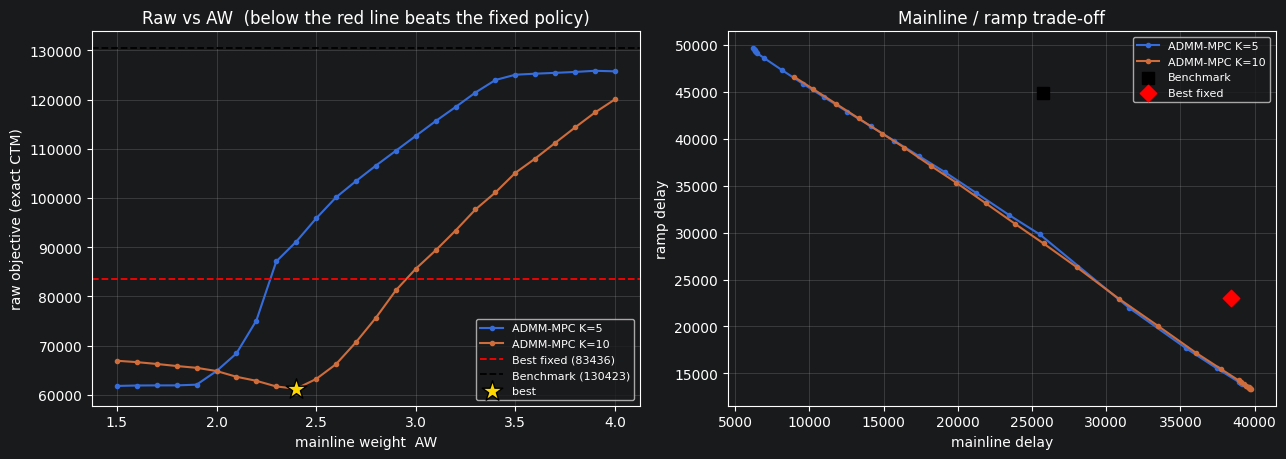

In [9]:
# ADMM-MPC vs Fixed policy & Benchmark  —  K x AW sweep, full table, and plots
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

#  what to sweep (more horizons / finer AW => slower; ~2-4 s per MPC run)
K_LIST  = [5, 10]                                 # MPC horizons to compare (add 20 if you want; slower)
AW_GRID = np.round(np.arange(1.5, 4.01, 0.1), 2)  # mainline weights to scan

BENCH_RAW = float(bt["raw_objective"])
FIXED_RAW = float(FIXED)
probs_by_K = {Kv: {Kh: build(Kh) for Kh in range(1, Kv + 1)} for Kv in K_LIST}

#  sweep K x AW
rows = []
for Kv in K_LIST:
    for AWv in AW_GRID:
        Tt = run_mpc(float(AWv), Kv, probs_by_K[Kv])
        rows.append({"K": Kv, "AW": float(AWv),
                     "mainline": Tt["mainline"], "ramp": Tt["local"],
                     "spillback": Tt["spillback"], "raw": Tt["raw"],
                     "beats_benchmark": Tt["raw"] < BENCH_RAW,
                     "beats_fixed":     Tt["raw"] < FIXED_RAW})
sweep = pd.DataFrame(rows)

#  >>> print ALL settings (not just the winners), with True/False flags
full = sweep.sort_values("raw").reset_index(drop=True)
n_bench = int(sweep["beats_benchmark"].sum()); n_fixed = int(sweep["beats_fixed"].sum())
print("Benchmark raw = %.1f   |   Best fixed policy (scale %.2f) raw = %.1f" % (BENCH_RAW, FIXED_S, FIXED_RAW))
print("All %d (K, AW) settings  |  beat benchmark: %d/%d  |  beat fixed: %d/%d\n"
      % (len(full), n_bench, len(full), n_fixed, len(full)))
with pd.option_context("display.max_rows", None):     # don't truncate the 52 rows
    try: display(full.round(2))
    except Exception: print(full.round(2).to_string(index=False))

#  best setting (lowest raw among those that beat the fixed policy)
winners = full[full["beats_fixed"]]
if len(winners):
    b = winners.iloc[0]
    print("\n BEST (lowest raw that beats fixed): K=%d, AW=%.2f -> raw %.1f   (%.1f%% below fixed, %.1f%% below benchmark)"
          % (b["K"], b["AW"], b["raw"], 100*(1-b["raw"]/FIXED_RAW), 100*(1-b["raw"]/BENCH_RAW)))
    print("    mainline %.0f | ramp %.0f | spillback %.0f" % (b["mainline"], b["ramp"], b["spillback"]))
else:
    b = None
    print("\nNothing in this grid beats the fixed policy — widen AW_GRID or change K_LIST.")

print("\nBest AW for each horizon:")
for Kv in K_LIST:
    s = sweep[sweep["K"] == Kv]; bk = s.loc[s["raw"].idxmin()]
    print("  K=%-2d best AW=%.2f -> raw %.1f  (%s)"
          % (Kv, bk["AW"], bk["raw"], "beats fixed" if bk["beats_fixed"] else "loses to fixed"))

#  visualize
fig, ax = plt.subplots(1, 2, figsize=(13, 4.7))
# (1) raw objective vs AW + reference lines  (a curve dipping BELOW the red line beats the fixed policy)
for Kv in K_LIST:
    s = sweep[sweep["K"] == Kv].sort_values("AW")
    ax[0].plot(s["AW"], s["raw"], "-o", ms=3, label="ADMM-MPC K=%d" % Kv)
ax[0].axhline(FIXED_RAW, ls="--", c="red",   lw=1.3, label="Best fixed (%.0f)" % FIXED_RAW)
ax[0].axhline(BENCH_RAW, ls="--", c="black", lw=1.3, label="Benchmark (%.0f)" % BENCH_RAW)
if b is not None:
    ax[0].scatter([b["AW"]], [b["raw"]], c="gold", edgecolor="k", marker="*", s=240, zorder=6, label="best")
ax[0].set_xlabel("mainline weight  AW"); ax[0].set_ylabel("raw objective (exact CTM)")
ax[0].set_title("Raw vs AW  (below the red line beats the fixed policy)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
# (2) mainline <-> ramp trade-off + benchmark/fixed markers
for Kv in K_LIST:
    s = sweep[sweep["K"] == Kv].sort_values("AW")
    ax[1].plot(s["mainline"], s["ramp"], "-o", ms=3, label="ADMM-MPC K=%d" % Kv)
ax[1].scatter([bt["mainline_delay"]], [bt["local_delay"]], c="black", marker="s", s=70, zorder=5, label="Benchmark")
ax[1].scatter([FIXED_FULL["mainline"]], [FIXED_FULL["local"]], c="red", marker="D", s=70, zorder=5, label="Best fixed")
ax[1].set_xlabel("mainline delay"); ax[1].set_ylabel("ramp delay")
ax[1].set_title("Mainline / ramp trade-off")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
# RELEASE AUDIT - how many cars each ramp was ASKED to release (MPC command),
# how many could REQUEST (queue-capped), and how many ACTUALLY entered the
# freeway (merge-capped) at every 15-second step. Run after Cells 1-3 (or 6).

import numpy as np, pandas as pd, pickle, cvxpy as cp

K_A, AW_A = K, AW                                  # headline config (K=10, AW=2.4)
probs_A = probs5 if "probs5" in globals() else {Kh: build(Kh) for Kh in range(1, K_A + 1)}

xc = dict(_x0); R = dict(_R0); B = {r: 0.0 for r in ramps}; Uc = 0.0
Tt = dict(mainline=0.0, local=0.0, fairness=0.0, doorway=0.0, safe=0.0, physical=0.0, spillback=0.0)
cmd_hist = {r: [] for r in ramps}; req_hist = {r: [] for r in ramps}; act_hist = {r: [] for r in ramps}
rows = []
for t in range(NS):
    Kh = min(K_A, NS - t); prob, P, v = probs_A[Kh]
    set_window(P, t, Kh, AW_A, np.array([xc[c] for c in cells]),
               np.array([R[r] + B[r] for r in ramps]), Uc)
    prob.solve(solver=cp.CLARABEL, warm_start=True)
    ok = prob.status in ("optimal", "optimal_inaccurate") and v.value is not None
    cmd = {r: (float(max(0.0, v.value[i, 0])) if ok else 0.0) for i, r in enumerate(ramps)}

    # --- exact non-convex plant, SAME calls as true_step, capturing every stage ---
    arr = {r: ARR_MULT * float(_cmd[r][t]) for r in ramps}
    av, req = _rreq(R_current=R, B_current=B, ramp_arrival_step=arr, commanded_release_step=cmd)
    o = _ctm(x_current=xc, q_in_boundary_step=float(_qb[t]), external_inflow_step=_ext[t],
             fixed_outflow_step=_fix[t], requested_release_step=req, inflow_capacity=_inf,
             outflow_capacity=_out, physical_capacity=_phys, movement_factor_by_cell=_mvf,
             wave_speed_ratio_by_cell=_wav, upstream_boundary_queue=Uc,
             exit_split_by_cell=_exb, merge_priority=_MP)
    xn, qo, qi, afo, ar, ci, Un, Ud = o[0], o[1], o[2], o[6], o[9], o[10], o[11], o[12]
    Rn, Bn, spk = _rnq(available_demand_step=av, actual_release_step=ar, ramp_max_queue_by_u=_rmqu)
    _, ld = _rdel(R, Rn, B, Bn, arr, cmd, req, ar, _dtE); _, _, Lf = _fair(Rn, _rnm, _rmqn, _gam)
    _, _, mc = _mds(xc, xn, qo, afo, _ttf, _dtE)
    cap = _cpen(qi, _ext[t], ci, xn, _inf, _safe, _phys, spk, _L1, _L2, _L3, _L4)
    for k2, vv in dict(mainline=mc + Ud, local=ld, fairness=Lf,
                       doorway=cap["total_doorway_penalty"], safe=cap["total_safe_threshold_penalty"],
                       physical=cap["total_physical_capacity_penalty"],
                       spillback=cap["total_spillback_penalty"]).items():
        Tt[k2] += vv

    sec = 16 * 3600 + t * 15
    row = {"step": t, "time": "%02d:%02d:%02d" % (sec // 3600, (sec % 3600) // 60, sec % 60)}
    for r in ramps:
        short = r.replace("u_", "")
        row[short + "_asked"] = round(cmd[r], 4)      # MPC command
        row[short + "_request"] = round(req[r], 4)    # capped by who is present
        row[short + "_released"] = round(ar[r], 4)    # accepted by the exact merge
        cmd_hist[r].append(float(cmd[r])); req_hist[r].append(float(req[r])); act_hist[r].append(float(ar[r]))
    rows.append(row)
    xc, R, B, Uc = xn, Rn, Bn, Un

Tt["raw"] = sum(Tt[k] for k in ["mainline", "local", "fairness", "doorway", "safe", "physical", "spillback"])
release_audit_df = pd.DataFrame(rows)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    try: display(release_audit_df)
    except NameError: print(release_audit_df.to_string(index=False))

print("\nPer-ramp totals over the 2 hours (vehicles):")
tot = pd.DataFrame({r.replace("u_", ""): {"asked_total": sum(cmd_hist[r]), "requested_total": sum(req_hist[r]),
      "released_total": sum(act_hist[r])} for r in ramps}).T.round(2)
print(tot.to_string())
print("\nexact-CTM raw objective of this audited run: %.6f  (headline MPC run: 61217.758)" % Tt["raw"])

pickle.dump({"K": K_A, "AW": AW_A, "arrival_multiplier": ARR_MULT,
             "applied_command_series": cmd_hist, "requested_series": req_hist,
             "actual_release_series": act_hist, "mpc_totals": Tt},
            open("mpc_release_schedule.pkl", "wb"))
print("saved mpc_release_schedule.pkl (feed this to Benchmark_MPC_replay.ipynb)")

,step,time,4th_asked,4th_request,4th_released,price_asked,price_request,price_released,mattie_asked,mattie_request,mattie_released,avila_asked,avila_request,avila_released
0,0,16:00:00,1.3800,1.3800,1.3800,3.0000,3.0000,3.0000,3.0600,3.0600,3.0600,0.0000,0.0000,0.0000
1,1,16:00:15,1.3800,1.3800,1.3800,3.0000,3.0000,3.0000,3.0600,3.0600,3.0600,0.0000,0.0000,0.0000
2,2,16:00:30,1.3800,1.3800,1.3800,3.0000,3.0000,3.0000,3.0600,3.0600,3.0600,0.0000,0.0000,0.0000
3,3,16:00:45,1.3800,1.3800,1.3800,3.0000,3.0000,3.0000,3.0600,3.0600,3.0600,0.0000,0.0000,0.0000
4,4,16:01:00,1.3800,1.3800,1.3800,3.0000,3.0000,3.0000,3.0600,3.0600,3.0600,0.0000,0.0000,0.0000
5,5,16:01:15,1.3800,1.3800,1.3800,3.0000,3.0000,3.0000,3.0600,3.0600,3.0600,0.0000,0.0000,0.0000
6,6,16:01:30,1.3800,1.3800,1.3800,3.0000,3.0000,3.0000,3.0600,3.0600,3.0600,0.0000,0.0000,0.0000
7,7,16:01:45,1.3800,1.3800,1.3800,3.0000,3.0000,3.0000,3.0600,3.0600,3.0600,0.0000,0.0000,0.0000
8,8,16:02:00,1.3800,1.3800,1.3800,3.0000,3.0000,3.0000,3.0600,3.0600,3.0600,0.0000,0.0000,0.0000
9,9,16:02:15,1.3800,1.3800,1.3800,3.0000,3.0000,3.0000,3.0600,3.0600,3.0600,0.0000,0.0000,0.0000



Per-ramp totals over the 2 hours (vehicles):
        asked_total  requested_total  released_total
4th          949.03           949.03          939.78
price       1915.51          1915.51         1899.76
mattie       669.17           669.17          669.17
avila        512.91           512.91          512.91

exact-CTM raw objective of this audited run: 87097.156012  (headline MPC run: 61217.758)
saved mpc_release_schedule.pkl (feed this to Benchmark_MPC_replay.ipynb)


In [11]:
# Paste/run this as a new final cell in ADMM_MPC.ipynb after the notebook variables/functions are loaded.
# It prints and exports, for every step and ramp:
#   ADMM-MPC command, requested release, and exact-CTM actual accepted release.

import pickle
import pandas as pd
import numpy as np
import time

def run_admm_mpc_with_release_audit(AWv=None, Kmax=None, print_full_table=True):
    if AWv is None:
        AWv = AW
    if Kmax is None:
        Kmax = K

    probs_audit = {Kh: build(Kh) for Kh in range(1, Kmax + 1)}

    xc = dict(_x0)
    R = dict(_R0)
    B = {r: 0.0 for r in ramps}
    Uc = 0.0

    totals = dict(
        mainline=0.0,
        local=0.0,
        fairness=0.0,
        doorway=0.0,
        safe=0.0,
        physical=0.0,
        spillback=0.0,
    )

    commanded_release_series = {r: [] for r in ramps}
    requested_release_series = {r: [] for r in ramps}
    actual_release_series = {r: [] for r in ramps}
    release_audit_rows = []
    nonoptimal_steps = []

    t0 = time.time()

    for t in range(NS):
        Kh = min(Kmax, NS - t)
        prob, P, v = probs_audit[Kh]

        set_window(
            P,
            t,
            Kh,
            float(AWv),
            np.array([xc[c] for c in cells], dtype=float),
            np.array([R[r] + B[r] for r in ramps], dtype=float),
            float(Uc),
        )

        prob.solve(solver=cp.CLARABEL, warm_start=True)

        if prob.status not in ("optimal", "optimal_inaccurate") or v.value is None:
            nonoptimal_steps.append((t, prob.status))
            command_step = {r: 0.0 for r in ramps}
        else:
            command_step = {
                r: float(max(0.0, v.value[i, 0]))
                for i, r in enumerate(ramps)
            }

        ramp_arrival_step = {
            r: ARR_MULT * float(_cmd[r][t])
            for r in ramps
        }

        available_demand_step, requested_release_step = _rreq(
            R_current=R,
            B_current=B,
            ramp_arrival_step=ramp_arrival_step,
            commanded_release_step=command_step,
        )

        ctm_out = _ctm(
            x_current=xc,
            q_in_boundary_step=float(_qb[t]),
            external_inflow_step=_ext[t],
            fixed_outflow_step=_fix[t],
            requested_release_step=requested_release_step,
            inflow_capacity=_inf,
            outflow_capacity=_out,
            physical_capacity=_phys,
            movement_factor_by_cell=_mvf,
            wave_speed_ratio_by_cell=_wav,
            upstream_boundary_queue=Uc,
            exit_split_by_cell=_exb,
            merge_priority=_MP,
        )

        x_next = ctm_out[0]
        q_out = ctm_out[1]
        q_in = ctm_out[2]
        actual_f_out = ctm_out[6]
        actual_release_step = ctm_out[9]
        controllable_onramp_in_step = ctm_out[10]
        U_next = ctm_out[11]
        upstream_delay = ctm_out[12]

        R_next, B_next, spillback_by_ramp = _rnq(
            available_demand_step=available_demand_step,
            actual_release_step=actual_release_step,
            ramp_max_queue_by_u=_rmqu,
        )

        _, local_delay = _rdel(
            R,
            R_next,
            B,
            B_next,
            ramp_arrival_step,
            command_step,
            requested_release_step,
            actual_release_step,
            _dtE,
        )

        _, _, fairness_penalty = _fair(R_next, _rnm, _rmqn, _gam)
        _, _, mainline_delay_clipped = _mds(xc, x_next, q_out, actual_f_out, _ttf, _dtE)
        mainline_delay = mainline_delay_clipped + upstream_delay

        cap = _cpen(
            q_in,
            _ext[t],
            controllable_onramp_in_step,
            x_next,
            _inf,
            _safe,
            _phys,
            spillback_by_ramp,
            _L1,
            _L2,
            _L3,
            _L4,
        )

        step_cost = dict(
            mainline=float(mainline_delay),
            local=float(local_delay),
            fairness=float(fairness_penalty),
            doorway=float(cap["total_doorway_penalty"]),
            safe=float(cap["total_safe_threshold_penalty"]),
            physical=float(cap["total_physical_capacity_penalty"]),
            spillback=float(cap["total_spillback_penalty"]),
        )

        for key in totals:
            totals[key] += step_cost[key]

        for r in ramps:
            commanded_release_series[r].append(float(command_step[r]))
            requested_release_series[r].append(float(requested_release_step[r]))
            actual_release_series[r].append(float(actual_release_step[r]))

            release_audit_rows.append({
                "step": t,
                "ramp": r,
                "commanded_release": float(command_step[r]),
                "requested_release": float(requested_release_step[r]),
                "actual_release": float(actual_release_step[r]),
                "ramp_arrival": float(ramp_arrival_step[r]),
                "available_demand_before_release": float(available_demand_step[r]),
                "physical_queue_before_R": float(R[r]),
                "spillback_before_B": float(B[r]),
                "physical_queue_after_R": float(R_next[r]),
                "spillback_after_B": float(B_next[r]),
                "solver_status": str(prob.status),
            })

        xc, R, B, Uc = x_next, R_next, B_next, U_next

    totals["capacity"] = totals["doorway"] + totals["safe"] + totals["physical"]
    totals["raw"] = sum(totals[k] for k in [
        "mainline", "local", "fairness", "doorway", "safe", "physical", "spillback"
    ])

    release_audit_df = pd.DataFrame(release_audit_rows)

    payload = {
        "K": int(Kmax),
        "AW": float(AWv),
        "METER": float(METER),
        "ARR_MULT": float(ARR_MULT),
        "ramps": list(ramps),
        "num_steps": int(NS),
        "commanded_release_series": commanded_release_series,
        "requested_release_series": requested_release_series,
        "actual_release_series": actual_release_series,
        "release_audit_records": release_audit_rows,
        "totals_exact_ctm_replay": totals,
        "nonoptimal_steps": nonoptimal_steps,
    }

    release_audit_df.to_csv("admm_mpc_release_audit.csv", index=False)

    with open("admm_mpc_release_audit.pkl", "wb") as fh:
        pickle.dump(payload, fh)

    print(f"ADMM-MPC release audit complete: K={Kmax}, AW={AWv}, METER={METER}")
    print(f"Runtime: {time.time() - t0:.1f}s")
    print("Saved admm_mpc_release_audit.csv")
    print("Saved admm_mpc_release_audit.pkl")
    print("Exact-CTM replay totals from audited commands:")
    print(pd.Series(totals).round(6).to_string())

    if nonoptimal_steps:
        print("WARNING: non-optimal MPC window solves:", nonoptimal_steps[:10], "...")

    if print_full_table:
        print("\nFull command/request/actual release table:")
        print(release_audit_df.to_string(index=False))
    else:
        print("\nFirst 20 rows of release audit:")
        print(release_audit_df.head(20).to_string(index=False))

    return release_audit_df, payload


release_audit_df, admm_mpc_release_payload = run_admm_mpc_with_release_audit(
    AWv=AW,
    Kmax=K,
    print_full_table=True,
)

ADMM-MPC release audit complete: K=5, AW=2.3, METER=1.2
Runtime: 2.1s
Saved admm_mpc_release_audit.csv
Saved admm_mpc_release_audit.pkl
Exact-CTM replay totals from audited commands:
mainline     25532.886195
local        29791.199346
fairness       281.442145
doorway          0.000000
safe             0.000000
physical         0.000000
spillback    31491.628403
capacity         0.000000
raw          87097.156089

Full command/request/actual release table:
 step     ramp  commanded_release  requested_release  actual_release  ramp_arrival  available_demand_before_release  physical_queue_before_R  spillback_before_B  physical_queue_after_R  spillback_after_B solver_status
    0    u_4th       1.380000e+00       1.380000e+00    1.380000e+00          1.38                         1.380000             0.000000e+00        0.000000e+00            3.404681e-09       0.000000e+00       optimal
    0  u_price       3.000000e+00       3.000000e+00    3.000000e+00          3.00                     

## Which K and AW to pick

For the lowest total raw objective, use:

K = 10, AW = 2.4

This gives raw ≈ 61,218, about 26.6% below the best fixed policy and 53.1% below the benchmark.

For a stronger all-around comparison against fixed policy, K = 10 and AW = 2.5 also beats the best fixed policy on mainline delay, ramp delay, spillback, and raw objective, but its raw objective is slightly worse than AW = 2.4.

For a faster lighter controller, K = 5 and AW = 1.5 gives raw ≈ 61,782, within about 1% of the best K = 10 result.

Higher AW lowers mainline delay but increases ramp delay and spillback. Therefore, AW should be selected based on the final objective: AW ≈ 2.4 for best raw objective, AW ≈ 2.5 for the strongest fixed-policy metric comparison, and higher AW only as mainline-priority sensitivity.